# Viscek Model Simualation

Read paper here: https://journals.aps.org/prl/pdf/10.1103/PhysRevLett.75.1226

## Initialization and plotting

The first cell sets the simulation parameters and assigns random positions and directions to the particles, all moving at the same speed. It also creates a quiver plot, where each arrow represents a particle and its direction of motion.


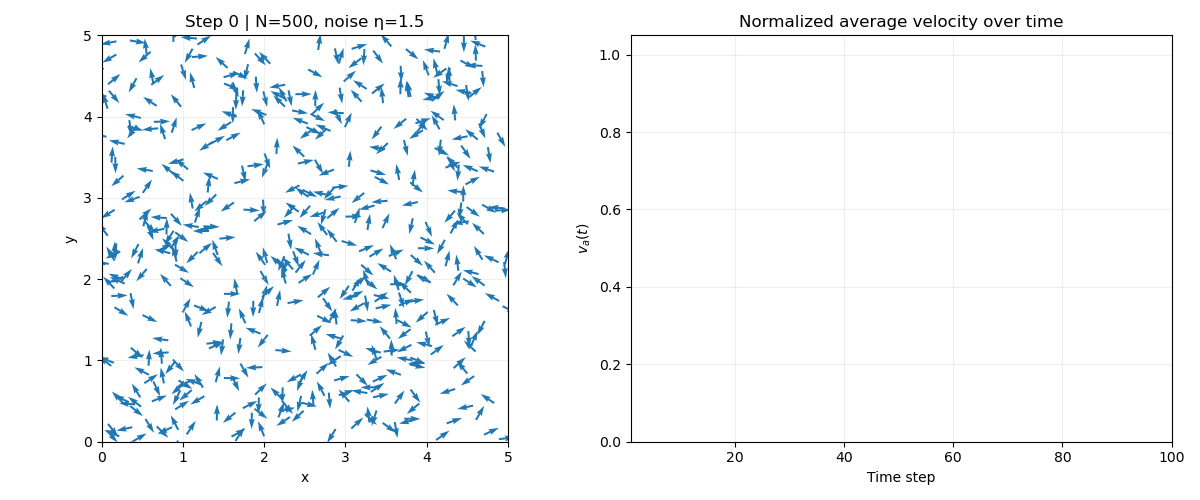

In [13]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


t = 0
N = 500          # number of particles
L = 5.0           # side length of the square box
r = 0.32          # interaction radius
v = 0.02          # speed (distance per time unit), constant for every particle
dt = 1.0          # time step
eta = 1.5         # angular noise width, in radians

xs = np.random.rand(N, 2) * L  # positions in [0, L) x [0, L)
thetas = np.random.rand(N) * 2 * np.pi


# Create synchronized live plots for the particles and their order parameter.
fig, (ax, ax_va) = plt.subplots(1, 2, figsize=(12, 5))
arrow_length = 0.04 * L  # enlarged for readability
arrows = ax.quiver(
    xs[:, 0], xs[:, 1],
    arrow_length * np.cos(thetas), arrow_length * np.sin(thetas),
    angles="xy", scale_units="xy", scale=1,
    pivot="tail", color="tab:blue", width=0.005,
)
ax.set(xlim=(0, L), ylim=(0, L), xlabel="x", ylabel="y")
ax.set_aspect("equal")
ax.grid(alpha=0.2)
title = ax.set_title(f"Step 0 | N={N}, noise η={eta}")

v_a_line, = ax_va.plot([], [], color="tab:orange")
ax_va.set(
    xlim=(1, 100), ylim=(0, 1.05),
    xlabel="Time step", ylabel=r"$v_a(t)$",
    title="Normalized average velocity over time",
)
ax_va.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## Time evolution

The second cell advances the simulation. At each step, particles align with the average direction of neighbors within radius $r$, with random angular noise controlled by $\eta$. All directions update simultaneously, then particles move and wrap across the periodic boundaries. The plot refreshes every few steps to show the motion.


In [14]:
# Run the setup cell above first to display the widget.
n_steps = 1000
plot_every = 5
v_a_history = np.empty(n_steps)
steps = np.arange(1, n_steps + 1)

for t in range(n_steps):
    new_thetas = np.zeros(N)
    for i in range(N):
        displacements = xs - xs[i]
        displacements = (displacements + L / 2) % L - L / 2 # Shortest displacement across the periodic box, in [-L/2, L/2).

        distances_squared = np.sum(displacements**2, axis=1) # Array of squared distances from particle i to all others.
        neighbors = distances_squared <= r**2 # Boolean array of which particles are neighbors of particle i (including itself).
        neighbor_thetas = thetas[neighbors] # Array of thetas of the neighbors of particle i (including itself).

        theta_mean = np.arctan2(np.mean(np.sin(neighbor_thetas)), np.mean(np.cos(neighbor_thetas))) # Mean direction of neighbors' thetas.
        delta_theta = (np.random.rand() - 0.5) * eta # Random noise in [-η/2, η/2).
        new_thetas[i] = theta_mean + delta_theta # Update theta of particle i to the mean of its neighbors' thetas, plus some noise.

    thetas = new_thetas

    # Each row is the velocity vector v * (cos(theta), sin(theta)).
    velocities = v * np.column_stack((np.cos(thetas), np.sin(thetas)))
    # Instantaneous normalized average velocity (the order parameter).
    v_a_history[t] = np.linalg.norm(np.sum(velocities, axis=0)) / (N * v)
    xs = xs + velocities * dt
    xs = xs % L  # wrap each coordinate back into [0, L)

    # Refresh the same arrows every few steps, and always show the final step.
    if (t + 1) % plot_every == 0 or t + 1 == n_steps:
        arrows.set_offsets(xs)
        arrows.set_UVC(
            arrow_length * np.cos(thetas),
            arrow_length * np.sin(thetas),
        )
        title.set_text(f"Step {t + 1} | N={N}, noise η={eta}")
        v_a_line.set_data(steps[:t + 1], v_a_history[:t + 1])
        ax_va.set_xlim(1, max(100, t + 1))
        # Refresh the particle field and v_a(t) together.
        fig.canvas.draw()
        fig.canvas.flush_events()


## Observations

I tried different values of the interaction radius $r$ and observed the following:

- **$r = 1$:** The particles aligned quite quickly and remained fairly evenly spread across the box.
- **$r = 0.5$:** The particles still aligned, but their spatial distribution was less uniform. Their overall direction of motion also tended to change slightly over time.
- **$r = 0.3$:** The particles formed relatively large clumps. Particles within each clump shared a similar orientation and tended to move together as a group.
- **$r = 0.1$:** The particles formed small, very concentrated clumps.

I also varied the noise parameter $\eta$, which controls the randomness in each particle's direction at each time step. Each arrow receives an independent random angular perturbation between $-\eta/2$ and $\eta/2$. Increasing $\eta$ allows larger random turns, making the arrows' motion more erratic, while decreasing $\eta$ makes their directions follow the average direction of their neighbors more closely.


In [12]:
# Estimate the steady-state order parameter by discarding the first half
# of the simulation as a transient and averaging the remaining values.
steady_state_start = n_steps // 2
v_a = np.mean(v_a_history[steady_state_start:])
ax_va.axhline(v_a, color="tab:red", linestyle="--", label="steady-state mean")
ax_va.legend()
fig.canvas.draw()
print(f"Final instantaneous v_a: {v_a_history[-1]:.4f}")
print(f"Steady-state mean v_a: {v_a:.4f}")

Final instantaneous v_a: 0.0000
Steady-state mean v_a: 0.0000
